# Modelling

## Import

In [4]:
import tensorflow as tf
import pandas as pd
import numpy as np
from keras_preprocessing.image import ImageDataGenerator
from keras import models, layers, losses, optimizers, metrics, callbacks
from keras.models import load_model

import matplotlib.pyplot as plt

In [5]:
# Experimental

# from tensorflow.keras.backend import clear_session

# clear_session()  # Clears old models from memory

In [6]:
# Experimental

# import tensorflow as tf

# gpus = tf.config.experimental.list_physical_devices('GPU')
# if gpus:
#     try:
#         for gpu in gpus:
#             tf.config.experimental.set_memory_growth(gpu, True)
#     except RuntimeError as e:
#         print(e)


In [7]:
#temporary solutions
%run ../scripts/save_utils.py
%run ../scripts/loss_recall_plot.py
%run ../notebooks/loader_modelling.ipynb

error: no such file with given path - ../save_files/evaluation/baseline_train_results.pkl.
error: no such file with given path - ../save_files/evaluation/baseline_test_results.pkl.
error: no such file with given path - ../save_files/train_log/baseline_train_log.pkl.
the object from ../save_files/variables/x_train.pkl has been successfully loaded.
the object from ../save_files/variables/y_train.pkl has been successfully loaded.
the object from ../save_files/variables/x_val.pkl has been successfully loaded.
the object from ../save_files/variables/y_val.pkl has been successfully loaded.
the object from ../save_files/variables/x_test.pkl has been successfully loaded.
the object from ../save_files/variables/y_test.pkl has been successfully loaded.


In [8]:
# ------------------------- models

#baseline = load_ml_model('../save_files/models/baseline.h5')

## Baseline model

### ImageDataGenerator

Let's initialize data generators. Most importantly, they will rescale vectorized images such that the values are going to be in range 0-1.

In [9]:
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

Now we need to specify the directories in which these images reside. I decided to keep original resolution of 512x512 pixels. The `batch_size` is relatively small to reduce memory usage.

In [10]:
train_generator = train_datagen.flow_from_dataframe(df_train, '..\\data\\raw\\merged_data\\',
                                                    x_col='image_path', y_col='label',
                                                    target_size=(512, 512), batch_size=8,
                                                    class_mode='categorical', validate_filenames=False)

validation_generator = val_datagen.flow_from_dataframe(df_val, '..\\data\\raw\\merged_data\\',
                                                       x_col='image_path', y_col='label',
                                                       target_size=(512, 512), batch_size=8,
                                                       class_mode='categorical', validate_filenames=False)

test_generator = test_datagen.flow_from_dataframe(df_test, '..\\data\\raw\\merged_data\\',
                                                  x_col='image_path', y_col='label',
                                                  target_size=(512, 512), batch_size=8,
                                                  class_mode='categorical', validate_filenames=False)

Found 4213 non-validated image filenames belonging to 4 classes.
Found 1405 non-validated image filenames belonging to 4 classes.
Found 1405 non-validated image filenames belonging to 4 classes.


We will also make a callback to invoke early stop. It will monitor validation loss, since we want to minimize it as much as possible.

In [11]:
stop_early_val_loss = callbacks.EarlyStopping(monitor='val_loss', patience=5)

Now we initialize a baseline model. It supposes to establish a basic level of performance to which we are going to compare the following tuned models. Layers and parameters of the baseline model are chosen somewhat randomly. However, we still need them to be adequate. I decided to go with *3 combinations of convolutional + maxpooling layers*.  
  
I also included `padding='same'` because the input size of some of the convolutional layers is odd and therefore the convolutional filters will crop some of the pixels and we don't want that.  
  
Notice that I have used `clear_session` to reset all variables that model might save before each use of the model (i.e. when re-running notebook).

In [12]:
tf.keras.backend.clear_session()

baseline = models.Sequential([
    
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(512, 512, 3)),
    layers.MaxPooling2D((2, 2), padding='same'),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2), padding='same'),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2), padding='same'),
    #layers.Conv2D(128, (3, 3), activation='relu'),
    #layers.MaxPooling2D((2, 2), padding='same'),
    #layers.Conv2D(256, (3, 3), activation='relu'),
    #layers.MaxPooling2D((2, 2), padding='same'),
    #layers.Conv2D(256, (3, 3), activation='relu'),
    #layers.MaxPooling2D((2, 2), padding='same'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'), #128
    #layers.Dropout(0.5),
    layers.Dense(32, activation='relu'), #64
    layers.Dense(4, activation='softmax')
])

baseline.compile(optimizer=optimizers.Adam(learning_rate=0.001), loss=losses.CategoricalCrossentropy(), metrics=metrics.Recall())
baseline.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 512, 512, 64)      1792      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 256, 256, 64)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 254, 254, 64)      36928     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 127, 127, 64)     0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 125, 125, 128)     73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 63, 63, 128)      0

The number of parameters is very large for the given problem, however, this is the point of a baseline model.

In [13]:
baseline_history = baseline.fit(train_generator,
                                epochs=30,  #60
                                verbose=1,
                                callbacks=[stop_early_val_loss],
                                validation_data=validation_generator,
                                steps_per_epoch=len(df_train)//train_generator.batch_size,
                                validation_steps=len(df_val)//validation_generator.batch_size,
                                )

Epoch 1/30
526/526 [==============================] - 97s 105ms/step - loss: 0.6626 - recall: 0.6692 - val_loss: 0.7828 - val_recall: 0.6550
Epoch 2/30
526/526 [==============================] - 47s 89ms/step - loss: 0.3343 - recall: 0.8625 - val_loss: 0.3962 - val_recall: 0.8493
Epoch 3/30
526/526 [==============================] - 46s 88ms/step - loss: 0.1591 - recall: 0.9386 - val_loss: 0.4081 - val_recall: 0.8821
Epoch 4/30
526/526 [==============================] - 47s 89ms/step - loss: 0.0797 - recall: 0.9743 - val_loss: 0.4410 - val_recall: 0.9171
Epoch 5/30
526/526 [==============================] - 46s 88ms/step - loss: 0.0566 - recall: 0.9812 - val_loss: 0.4494 - val_recall: 0.9100
Epoch 6/30
526/526 [==============================] - 45s 86ms/step - loss: 0.0560 - recall: 0.9829 - val_loss: 0.4395 - val_recall: 0.9036
Epoch 7/30
526/526 [==============================] - 45s 86ms/step - loss: 0.0403 - recall: 0.9860 - val_loss: 0.4938 - val_recall: 0.9179


Now we save the model.

In [14]:
baseline.save('../save_files/models/baseline.h5')

baseline_train_log = baseline_history.history
save_data(baseline_train_log, 'train_log', '../save_files/train_log/baseline_train_log.pkl')

object successfully saved to: ../save_files/train_log/baseline_train_log.pkl.


### Baseline model evaluation

And visualize the training process.

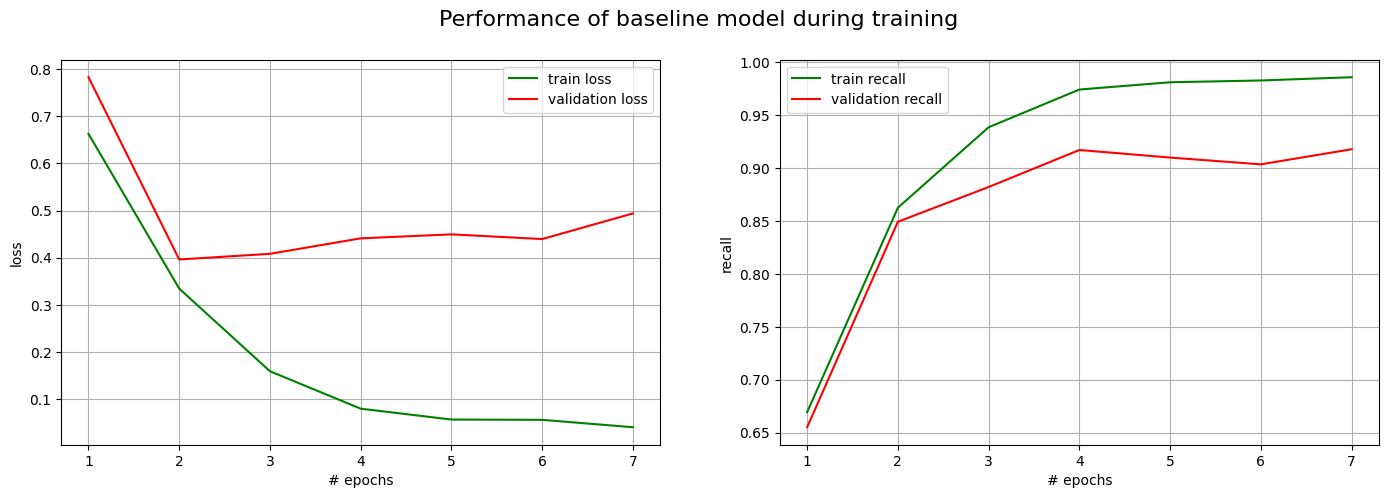

In [15]:
loss_recall_plot(baseline_train_log, 'Performance of baseline model during training')

Let's now evaluate the baseline model on the train and test data.

In [16]:
baseline_train_results = baseline.evaluate(train_generator, batch_size=32, return_dict=True)
baseline_test_results = baseline.evaluate(test_generator, batch_size=32, return_dict=True)

save_data(baseline_train_results, 'evaluation_data', '../save_files/evaluation/baseline_train_results.pkl')
save_data(baseline_test_results, 'evaluation_data', '../save_files/evaluation/baseline_test_results.pkl')

176/176 [==============================] - 12s 67ms/step - loss: 0.5031 - recall: 0.9238
object successfully saved to: ../save_files/evaluation/baseline_train_results.pkl.
object successfully saved to: ../save_files/evaluation/baseline_test_results.pkl.


In [17]:
print('Evaluation results for baseline model:\n')
print('train loss:   ', baseline_train_results['loss'])
print('train recall: ', baseline_train_results['recall'])
print()
print('test loss:    ', baseline_test_results['loss'])
print('test recall:  ', baseline_test_results['recall'])

Evaluation results for baseline model:

train loss:    0.009370403364300728
train recall:  0.9971516728401184

test loss:     0.5030723214149475
test recall:   0.9238434433937073


Even though test results seem relatively good (0.93), we observe severe overfitting. However, we've established the basic performance for the future models and can move on.

## Further

Now when the baseline performance level is set, we will try several tecnhiques to reduce (or hopefully eliminate completely) overfitting and get higher test metrics.
  
Quick overview of possible solutions:
1. Data augmentation - makes random changes in the input images to make the train set more generalized and therefore get more generalized model.
2. Less parameters - the baseline model has *65,145,060* parameters (or weights), major part of which (*65,028,224*) is generated on the first Dense layer. The reason for this is that input size (or resolution) of the feature maps from the last maxpooling layers is too big (this also will be important in the following techniques). This number of parameters may be the reason why baseline model overfits so quickly and so severly. 
3. Make the resolution of images in the initial input smaller - doing this, we will be able to reduce the dimensionality much quicker, however we will have to keep in mind that artificial downscaling will cause the loss of fine-grained information.
4. Make more convolutional + maxpooling layers - we will be able to work with initial resolution without getting a huge number of parameters because at the end of convolutional base the resolution of feature maps will be much smaller and therefore less parameters will be generated on the Dense layers.
    

## Augmentation

Let's introduce some random augmentation to initial images. This way we will be able to train the model on the more generalized data to hopefully reduce overfitting.

In [18]:
train_datagen_aug = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

train_generator_aug = train_datagen_aug.flow_from_dataframe(df_train, '..\\data\\raw\\merged_data\\',
                                                            x_col='image_path', y_col='label',
                                                            target_size=(512, 512), batch_size=8,
                                                            class_mode='categorical', validate_filenames=False)

Found 4213 non-validated image filenames belonging to 4 classes.


We will use the same architecture of model as before:

In [19]:
tf.keras.backend.clear_session()

augmented_model = models.Sequential([
    
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(512, 512, 3)),
    layers.MaxPooling2D((2, 2), padding='same'),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2), padding='same'),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2), padding='same'),
    #layers.Conv2D(128, (3, 3), activation='relu'),
    #layers.MaxPooling2D((2, 2), padding='same'),
    #layers.Conv2D(256, (3, 3), activation='relu'),
    #layers.MaxPooling2D((2, 2), padding='same'),
    #layers.Conv2D(256, (3, 3), activation='relu'),
    #layers.MaxPooling2D((2, 2), padding='same'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'), #128
    #layers.Dropout(0.5),
    layers.Dense(32, activation='relu'), #64
    layers.Dense(4, activation='softmax')
])

augmented_model.compile(optimizer=optimizers.Adam(learning_rate=0.001), loss=losses.CategoricalCrossentropy(), metrics=metrics.Recall())
augmented_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 512, 512, 64)      1792      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 256, 256, 64)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 254, 254, 64)      36928     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 127, 127, 64)     0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 125, 125, 128)     73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 63, 63, 128)      0

In [20]:
augmented_model_history = augmented_model.fit(train_generator_aug,
                                              epochs=60,  #60
                                              verbose=1,
                                              callbacks=[stop_early_val_loss],
                                              validation_data=validation_generator,
                                              steps_per_epoch=len(df_train)//train_generator.batch_size,
                                              validation_steps=len(df_val)//validation_generator.batch_size,
                                              )

Epoch 1/60
526/526 [==============================] - 154s 293ms/step - loss: 1.0527 - recall: 0.2870 - val_loss: 1.2187 - val_recall: 0.3071
Epoch 2/60
526/526 [==============================] - 154s 293ms/step - loss: 0.8398 - recall: 0.5103 - val_loss: 0.8337 - val_recall: 0.5921
Epoch 3/60
526/526 [==============================] - 159s 302ms/step - loss: 0.7458 - recall: 0.5983 - val_loss: 0.6080 - val_recall: 0.6721
Epoch 4/60
526/526 [==============================] - 155s 294ms/step - loss: 0.7252 - recall: 0.6276 - val_loss: 0.6312 - val_recall: 0.6657
Epoch 5/60
526/526 [==============================] - 155s 295ms/step - loss: 0.6926 - recall: 0.6559 - val_loss: 0.8812 - val_recall: 0.5893
Epoch 6/60
526/526 [==============================] - 155s 295ms/step - loss: 0.6642 - recall: 0.6697 - val_loss: 0.6122 - val_recall: 0.7093
Epoch 7/60
526/526 [==============================] - 155s 295ms/step - loss: 0.6549 - recall: 0.6730 - val_loss: 0.5926 - val_recall: 0.7371
Epoch 

In [21]:
augmented_model.save('../save_files/models/augmented_model.h5')

augmented_model_train_log = augmented_model_history.history
save_data(augmented_model_train_log, 'train_log', '../save_files/train_log/augmented_model_train_log.pkl')

object successfully saved to: ../save_files/train_log/augmented_model_train_log.pkl.


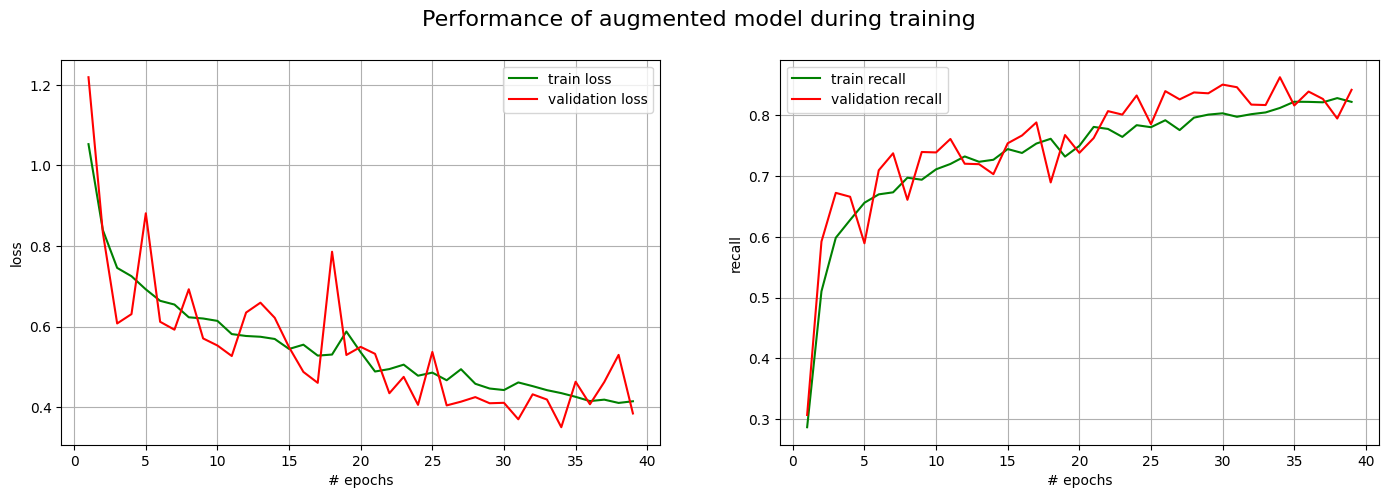

In [22]:
loss_recall_plot(augmented_model_train_log, 'Performance of augmented model during training')

We observe high spikes for the validation. The reason for this might be the augmentation of the train data. In addition, we see that metrics aren't as high as for the baseline model.  
However, even with these spikes we see that there's no overfitting overall. So we will consider this approach helpful.  
  
We might want to make the augmentation a little smaller to see if it will resolve the issue. To do this, we'll need to initialize a new generator.

In [23]:
train_datagen_aug_small = ImageDataGenerator(
    rescale=1./255,
    rotation_range=5,
    width_shift_range=0.05,
    height_shift_range=0.05,
    shear_range=0.05,
    zoom_range=0.05,
    horizontal_flip=False
)

train_generator_aug_small = train_datagen_aug_small.flow_from_dataframe(df_train, '..\\data\\raw\\merged_data\\',
                                                                        x_col='image_path', y_col='label',
                                                                        target_size=(512, 512), batch_size=8,
                                                                        class_mode='categorical', validate_filenames=False)

Found 4213 non-validated image filenames belonging to 4 classes.


In [24]:
tf.keras.backend.clear_session()

augmented_small_model = models.Sequential([
    
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(512, 512, 3)),
    layers.MaxPooling2D((2, 2), padding='same'),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2), padding='same'),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2), padding='same'),
    #layers.Conv2D(128, (3, 3), activation='relu'),
    #layers.MaxPooling2D((2, 2), padding='same'),
    #layers.Conv2D(256, (3, 3), activation='relu'),
    #layers.MaxPooling2D((2, 2), padding='same'),
    #layers.Conv2D(256, (3, 3), activation='relu'),
    #layers.MaxPooling2D((2, 2), padding='same'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'), #128
    #layers.Dropout(0.5),
    layers.Dense(32, activation='relu'), #64
    layers.Dense(4, activation='softmax')
])

augmented_small_model.compile(optimizer=optimizers.Adam(learning_rate=0.001), loss=losses.CategoricalCrossentropy(), metrics=metrics.Recall())
augmented_small_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 512, 512, 64)      1792      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 256, 256, 64)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 254, 254, 64)      36928     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 127, 127, 64)     0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 125, 125, 128)     73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 63, 63, 128)      0

In [25]:
augmented_small_model_history = augmented_small_model.fit(train_generator_aug_small,
                                                          epochs=60,  #60
                                                          verbose=1,
                                                          callbacks=[stop_early_val_loss],
                                                          validation_data=validation_generator,
                                                          steps_per_epoch=len(df_train)//train_generator.batch_size,
                                                          validation_steps=len(df_val)//validation_generator.batch_size,
                                                          )

Epoch 1/60
526/526 [==============================] - 147s 279ms/step - loss: 0.8185 - recall: 0.5460 - val_loss: 0.5235 - val_recall: 0.7821
Epoch 2/60
526/526 [==============================] - 146s 278ms/step - loss: 0.5256 - recall: 0.7648 - val_loss: 0.3893 - val_recall: 0.8300
Epoch 3/60
526/526 [==============================] - 146s 278ms/step - loss: 0.4434 - recall: 0.8069 - val_loss: 0.3955 - val_recall: 0.8343
Epoch 4/60
526/526 [==============================] - 147s 279ms/step - loss: 0.3948 - recall: 0.8321 - val_loss: 0.3991 - val_recall: 0.8236
Epoch 5/60
526/526 [==============================] - 148s 281ms/step - loss: 0.3635 - recall: 0.8402 - val_loss: 0.3149 - val_recall: 0.8793
Epoch 6/60
526/526 [==============================] - 147s 279ms/step - loss: 0.3401 - recall: 0.8611 - val_loss: 0.4252 - val_recall: 0.8400
Epoch 7/60
526/526 [==============================] - 146s 278ms/step - loss: 0.3291 - recall: 0.8623 - val_loss: 0.2864 - val_recall: 0.8807
Epoch 

In [27]:
augmented_small_model.save('../save_files/models/augmented_model_small.h5')

In [28]:
augmented_small_model_train_log = augmented_small_model_history.history
save_data(augmented_small_model_train_log, 'train_log', '../save_files/train_log/augmented_small_model_train_log.pkl')

object successfully saved to: ../save_files/train_log/augmented_small_model_train_log.pkl.
